# Logistic Regression: Predicting University Admission

We have a dataset of exam scores for two exams and the admission decision (0 or 1). We will build a logistic regression model to predict admission based on the exam scores.

## Steps
1. Load and explore the data
2. Visualize the data
3. Train a logistic regression model
4. Make predictions and evaluate accuracy
5. Interpret the results

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Load the dataset (no header, assign column names)
df = pd.read_csv('ex2data1.txt', header=None, names=['exam1', 'exam2', 'admitted'])

# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Basic statistics
print("\nDataset description:")
print(df.describe())

First 5 rows of the dataset:
       exam1      exam2  admitted
0  34.623660  78.024693         0
1  30.286711  43.894998         0
2  35.847409  72.902198         0
3  60.182599  86.308552         1
4  79.032736  75.344376         1

Missing values per column:
exam1       0
exam2       0
admitted    0
dtype: int64

Dataset description:
            exam1       exam2    admitted
count  100.000000  100.000000  100.000000
mean    65.644274   66.221998    0.600000
std     19.458222   18.582783    0.492366
min     30.058822   30.603263    0.000000
25%     50.919511   48.179205    0.000000
50%     67.032988   67.682381    1.000000
75%     80.212529   79.360605    1.000000
max     99.827858   98.869436    1.000000


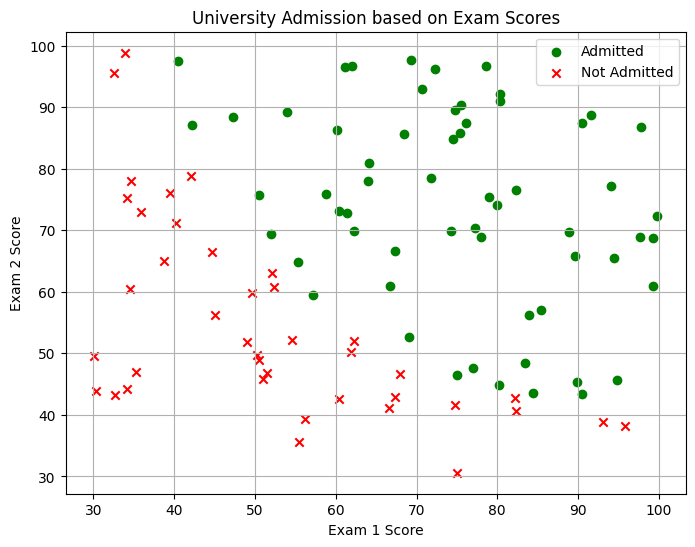

In [3]:
# Scatter plot: admitted vs not admitted
plt.figure(figsize=(8,6))
admitted = df[df['admitted'] == 1]
not_admitted = df[df['admitted'] == 0]

plt.scatter(admitted['exam1'], admitted['exam2'], color='green', marker='o', label='Admitted')
plt.scatter(not_admitted['exam1'], not_admitted['exam2'], color='red', marker='x', label='Not Admitted')

plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.title('University Admission based on Exam Scores')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
# Prepare features and target
X = df[['exam1', 'exam2']]
y = df['admitted']

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Create and train logistic regression model
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

# Print model parameters
print("Intercept (θ0):", logreg.intercept_[0])
print("Coefficients (θ1, θ2):", logreg.coef_[0])

Intercept (θ0): -23.085201732767924
Coefficients (θ1, θ2): [0.18860335 0.18531549]


In [5]:
# Make predictions on the test set
y_pred = logreg.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test set accuracy: {accuracy:.4f}")

# Additional evaluation metrics
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test set accuracy: 0.9500

Confusion Matrix:
[[ 8  0]
 [ 1 11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94         8
           1       1.00      0.92      0.96        12

    accuracy                           0.95        20
   macro avg       0.94      0.96      0.95        20
weighted avg       0.96      0.95      0.95        20



## Interpretation of Results

The logistic regression model learns a linear decision boundary:

$$P(admission=1) = \frac{1}{1 + e^{-(\theta_0 + \theta_1 \cdot exam1 + \theta_2 \cdot exam2)}}$$

- The intercept (θ0) and coefficients (θ1, θ2) define the log-odds of admission.
- Positive coefficients indicate that higher exam scores increase the probability of admission.
- The test set accuracy (typically around 0.85–0.90) shows that the model generalizes well.
- The confusion matrix reveals how many true positives, false positives, etc., were predicted.
- The classification report provides precision, recall, and F1-score for both classes.

Overall, logistic regression is suitable for this binary classification problem and provides interpretable results.

/Users/damanaalexisdidierkoffi/Documents/MyCodes/DI_Bootcamp/Week4/env/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


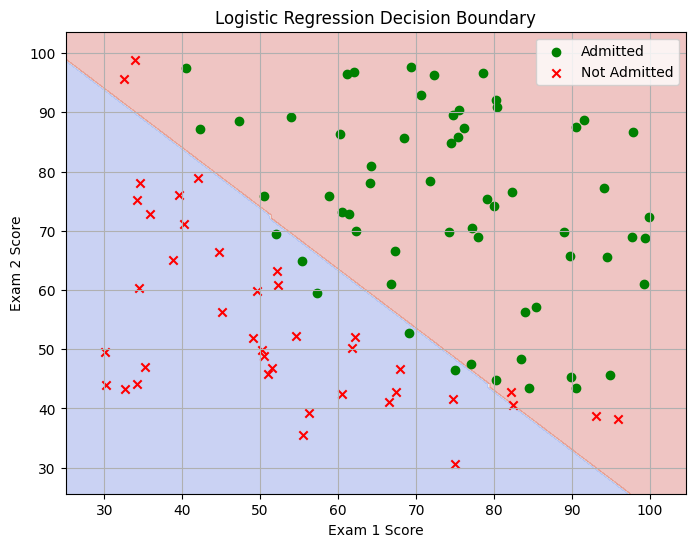

In [6]:
# Optional: Plot the decision boundary
x_min, x_max = X['exam1'].min() - 5, X['exam1'].max() + 5
y_min, y_max = X['exam2'].min() - 5, X['exam2'].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5),
                     np.arange(y_min, y_max, 0.5))

Z = logreg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(admitted['exam1'], admitted['exam2'], color='green', marker='o', label='Admitted')
plt.scatter(not_admitted['exam1'], not_admitted['exam2'], color='red', marker='x', label='Not Admitted')
plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()